# Kmeans

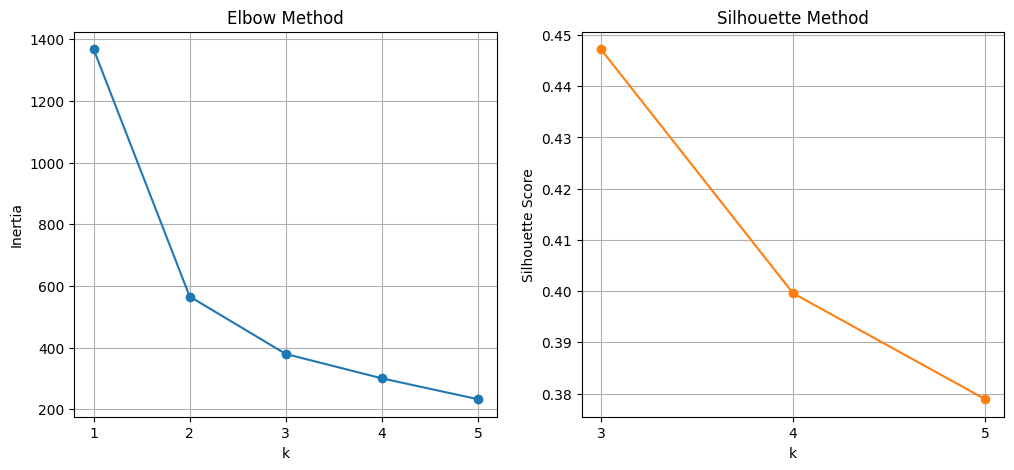

Mejor k según silhouette: 3

Tamaño por cluster:
cluster
0     87
1    123
2    132
Name: count, dtype: int64

Centroides (escala original):
         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
cluster                                                               
0             47.525287      18.762069         196.896552  3902.011494
1             47.504878      14.982114         217.186992  5076.016260
2             38.208333      18.110606         188.401515  3584.659091

Medias por cluster:
         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
cluster                                                               
0             47.525287      18.762069         196.896552  3902.011494
1             47.504878      14.982114         217.186992  5076.016260
2             38.208333      18.110606         188.401515  3584.659091

Ejemplos y predicción de cluster:
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  pred_cluster
0            3

In [6]:
# Ejemplo autocontenido de KMeans con "palmer penguins"
# Incluye: carga, preprocesamiento, determinación de k (elbow + silueta), ajuste final y ejemplo de predicción.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1) Cargar y limpiar datos
df = pd.read_csv('../data/penguins.csv')             # convertir a DataFrame si es un Bunch
df = df.dropna(subset=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g'])
features = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
X = df[features].copy()

# 2) Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) Elbow (inertia) para k = 1..10
ks = list(range(1,6))
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(ks, inertias, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(ks)
plt.grid(True)


# 4) Silhouette score para k = 3..10
ks2 = list(range(3,6))
sil_scores = []
for k in ks2:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.subplot(1, 2, 2)
plt.plot(ks2, sil_scores, '-o', color='C1')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.xticks(ks2)
plt.grid(True)
plt.show()

# 5) Selección automática de k por mejor silhouette (puede ajustar manualmente)
best_k = ks2[int(np.argmax(sil_scores))]
print(f"Mejor k según silhouette: {best_k}")

# 6) Ajuste final de KMeans con best_k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
labels = kmeans.fit_predict(X_scaled)
df['cluster'] = labels

# Mostrar tamaños y centroides (en escala original)
print("\nTamaño por cluster:")
print(df['cluster'].value_counts().sort_index())

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df.index.name = 'cluster'
print("\nCentroides (escala original):")
print(centers_df)

print("\nMedias por cluster:")
print(df.groupby('cluster')[features].mean())


# 8) Ejemplo de predicción
# Tomar una fila real y una sintética
ejemplo_real = X.iloc[0:1].copy()  # primera fila del dataset
ejemplo_sint = pd.DataFrame([{
    'bill_length_mm': 50.0,
    'bill_depth_mm': 17.0,
    'flipper_length_mm': 210.0,
    'body_mass_g': 5000.0
}])

to_predict = pd.concat([ejemplo_real, ejemplo_sint], ignore_index=True)
to_predict_scaled = scaler.transform(to_predict)
pred_clusters = kmeans.predict(to_predict_scaled)

print("\nEjemplos y predicción de cluster:")
out = to_predict.copy()
out['pred_cluster'] = pred_clusters
print(out.reset_index(drop=True))